# get-DA-analysis-figure
6.17.24

Want to make some bar plots.

In [1]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

# plotting templates
sns.set(context="talk", style="ticks") 
pal = sns.color_palette("tab10")

#### Configs

In [2]:
cust_palette = ["#ff7f0e", "#1f77b4", "#2ca02c"]

#### Construct the plotting dataframe

In [3]:
cols = ["cohort", "Lupine_up", "Lupine_down", "No Impute_up", "No Impute_down"]
plotter = pd.DataFrame(columns=cols)

plotter["cohort"] = ["BRCA", "CCRCC", "COAD", "GBM", "HGSC", 
                     "HNSCC", "LSCC", "LUAD", "PDAC", "UCEC"]

plotter["Lupine_up"] = [967, 102, 15, 252, 5, 36, 74, 10, 47, 33]
plotter["Lupine_down"] =[199, 462, 256, 1288, 269, 176, 306, 110, 126, 344]

plotter["No Impute_up"] = [3, 71, 9, 169, 1, 23, 60, 9, 22, 15]
plotter["No Impute_down"] = [56, 308, 183, 785, 76, 107, 230, 78, 83, 211]

#### Do some data wrangling

In [4]:
# Break out into separate up- and down-reg dataframes
up_reg_plotter = plotter[["cohort", "Lupine_up", "No Impute_up"]]
down_reg_plotter = plotter[["cohort", "Lupine_down", "No Impute_down"]]

# Melt the up-regulated dataframe
up_reg_melt = up_reg_plotter.melt("cohort")
up_reg_melt.columns = ["cohort", "method", "proteins"]

methods = [x.split("_")[0] for x in up_reg_melt.method]

up_reg_melt["method"] = methods

# Repeat for the down-regulated dataframe
down_reg_melt = down_reg_plotter.melt("cohort")
down_reg_melt.columns = ["cohort", "method", "proteins"]

methods1 = [x.split("_")[0] for x in down_reg_melt.method]

down_reg_melt["method"] = methods1

#### Sort by number of proteins
I think this will make the barplots more visually interpretable. 

In [5]:
up_reg_melt = up_reg_melt.sort_values("proteins", ascending=False)
down_reg_melt = down_reg_melt.sort_values("proteins", ascending=False)

#### Side-by-side plots
For both up- and down-regulated 

In [6]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# # The up-regulated results
# sns.barplot(
#     data=up_reg_melt, 
#     x="cohort", 
#     y="proteins", 
#     hue="method", 
#     palette=cust_palette, 
#     saturation=1, 
#     ax=ax1
# )
# ax1.set_title("Up Regulated", pad=20, size=24)
# ax1.set_xlabel("")
# ax1.set_ylabel("Proteins", labelpad=6, size=20)
# ax1.tick_params(axis='x', labelrotation=90)
# ax1.set_ylim(top=1000)
# ax1.legend(title="", edgecolor="k", prop={'size': 16})

# # The down-regulated results
# sns.barplot(
#     data=down_reg_melt, 
#     x="cohort", 
#     y="proteins", 
#     hue="method", 
#     palette=cust_palette, 
#     saturation=1, 
#     ax=ax2
# )
# ax2.set_title("Down Regulated", pad=20, size=24)
# ax2.set_xlabel("")
# ax2.set_ylabel("")
# ax2.tick_params(axis='x', labelrotation=90)
# ax2.set_ylim(top=2000)
# ax2.get_legend().remove()

# plt.tight_layout()
# plt.show()
# #plt.savefig("../results/DE-within-cohort.png", dpi=250, bbox_inches="tight")

#### Add naive impute

In [7]:
# up_reg_plotter["Col Min_up"] = []
# down_reg_plotter["Col Min_down"] = []

up_reg_plotter["Gaussian Random Sample_up"] = [45, 56, 7, 147, 2, 18, 47, 6, 22, 8]
down_reg_plotter["Gaussian Random Sample_down"] = [65, 296, 186, 793, 75, 107, 206, 70, 68, 217]

/tmp/ipykernel_1532515/1036850303.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  up_reg_plotter["Gaussian Random Sample_up"] = [45, 56, 7, 147, 2, 18, 47, 6, 22, 8]
/tmp/ipykernel_1532515/1036850303.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  down_reg_plotter["Gaussian Random Sample_down"] = [65, 296, 186, 793, 75, 107, 206, 70, 68, 217]


#### Repeat the data wrangling

In [8]:
# Melt the up-regulated dataframe
up_reg_melt = up_reg_plotter.melt("cohort")
up_reg_melt.columns = ["cohort", "method", "proteins"]

methods = [x.split("_")[0] for x in up_reg_melt.method]

up_reg_melt["method"] = methods

# Repeat for the down-regulated dataframe
down_reg_melt = down_reg_plotter.melt("cohort")
down_reg_melt.columns = ["cohort", "method", "proteins"]

methods1 = [x.split("_")[0] for x in down_reg_melt.method]

down_reg_melt["method"] = methods1

#### Sort by bar height
For the Lupine impute values. 

In [9]:
up_reg_melt = up_reg_melt.sort_values("proteins", ascending=False)
down_reg_melt = down_reg_melt.sort_values("proteins", ascending=False)

#### Side-by-side bar plots

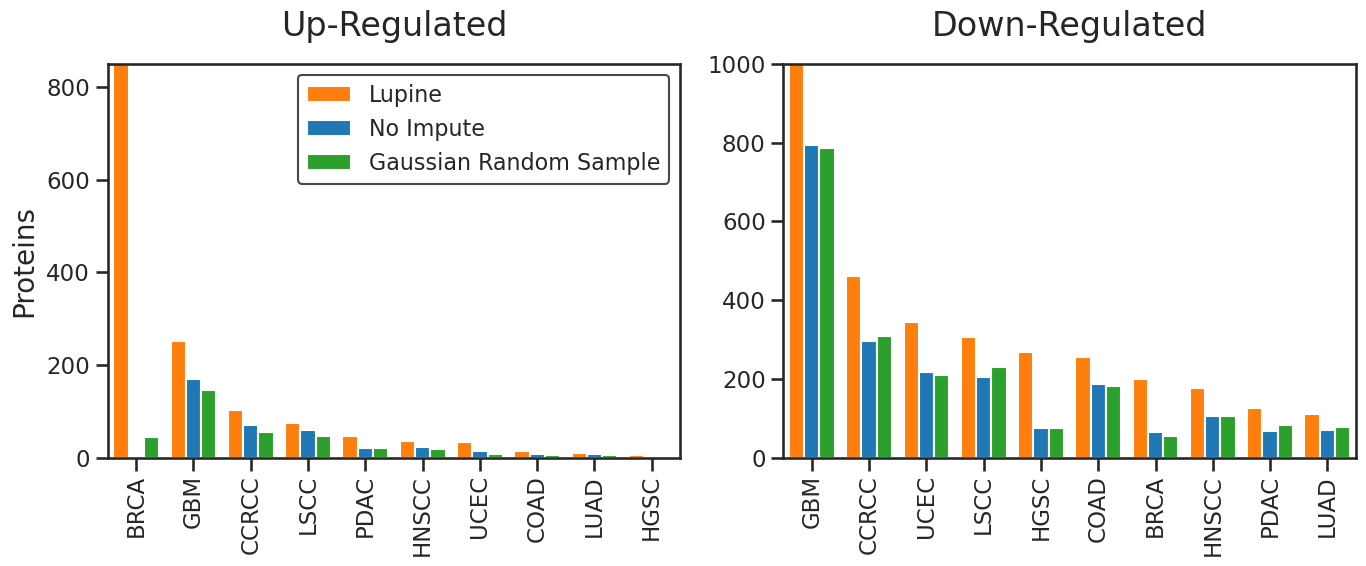

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# The up-regulated results
sns.barplot(
    data=up_reg_melt, 
    x="cohort", 
    y="proteins", 
    hue="method", 
    palette=cust_palette, 
    saturation=1, 
    ax=ax1
)
ax1.set_title("Up-Regulated", pad=20, size=24)
ax1.set_xlabel("")
ax1.set_ylabel("Proteins", labelpad=6, size=20)
ax1.tick_params(axis='x', labelrotation=90)
ax1.set_ylim(top=850)
ax1.legend(title="", edgecolor="k", prop={'size': 16})

# The down-regulated results
sns.barplot(
    data=down_reg_melt, 
    x="cohort", 
    y="proteins", 
    hue="method", 
    palette=cust_palette, 
    saturation=1, 
    ax=ax2
)
ax2.set_title("Down-Regulated", pad=20, size=24)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', labelrotation=90)
ax2.set_ylim(top=1000)
ax2.get_legend().remove()

plt.tight_layout()
plt.show()
#plt.savefig("../figures/DE-barplots-figure-V3.pdf", bbox_inches="tight")
#plt.savefig("figures/DE-barplots-figure.png", dpi=250, bbox_inches="tight")